In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets files mkechinov/ecommerce-behavior-data-from-multi-category-store

name                size  creationDate                
------------  ----------  --------------------------  
2019-Nov.csv  9006762395  2019-12-09 20:52:13.431000  
2019-Oct.csv  5668612855  2019-12-09 20:51:21.345000  


In [ ]:
!kaggle datasets download \
  -d mkechinov/ecommerce-behavior-data-from-multi-category-store \
  -f 2019-Oct.csv

Dataset URL: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store
License(s): copyright-authors
2019-Oct.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!ls -lh

total 6.9G
-rw-r--r-- 1 root root 3.9G Aug 27 18:54 2019-Oct.csv
-rw-r--r-- 1 root root 1.7G Dec  9  2019 2019-Oct.csv.zip
-rw-r--r-- 1 root root 1.4G Aug 27 18:54 ecommerce.db
drwxr-xr-x 1 root root 4.0K Aug 24 13:21 sample_data


In [ ]:
!unzip -oq 2019-Oct.csv.zip

In [ ]:
!ls -lh

total 8.3G
-rw-r--r-- 1 root root 5.3G Dec  9  2019 2019-Oct.csv
-rw-r--r-- 1 root root 1.7G Dec  9  2019 2019-Oct.csv.zip
-rw-r--r-- 1 root root 1.4G Aug 27 18:54 ecommerce.db
drwxr-xr-x 1 root root 4.0K Aug 24 13:21 sample_data


# E-commerce Behavior Analysis

## Data Science Capstone Project

**Dataset:** E-commerce Behavior Data from Multi-Category Store

**Analysis Period:** October 2019

**Project Date:** August 2026

**Author:** Said Uzun

## Project Objectives

The main objective of this project is to analyze user behavior in an e-commerce platform and develop a recommendation system based on historical interaction data.

The project aims to:

- Understand customer behavior
- Analyze product interactions
- Identify purchasing patterns
- Build a recommendation model
- Present business insights through visualizations

## Import Libraries

The required Python libraries are imported for data processing, SQL analysis, and visualization.

In [ ]:
import pandas as pd
import duckdb
import polars as pl
import matplotlib.pyplot as plt

## Data Dictionary

The table below summarizes the variables available in the dataset and their meanings.

In [ ]:
data_dictionary = pd.DataFrame({
    "Column": [
        "event_time",
        "event_type",
        "product_id",
        "category_id",
        "category_code",
        "brand",
        "price",
        "user_id",
        "user_session"
    ],
    "Data Type": [
        "Timestamp",
        "String",
        "Integer",
        "Integer",
        "String",
        "String",
        "Float",
        "Integer",
        "String"
    ],
    "Description": [
        "Timestamp of the user interaction.",
        "Type of interaction (view, cart, purchase).",
        "Unique identifier of the product.",
        "Unique identifier of the product category.",
        "Hierarchical category name of the product.",
        "Brand of the product.",
        "Displayed product price.",
        "Unique identifier of the user.",
        "Unique identifier of the browsing session."
    ]
})

data_dictionary

,Column,Data Type,Description
0,event_time,Timestamp,Timestamp of the user interaction.
1,event_type,String,"Type of interaction (view, cart, purchase)."
2,product_id,Integer,Unique identifier of the product.
3,category_id,Integer,Unique identifier of the product category.
4,category_code,String,Hierarchical category name of the product.
5,brand,String,Brand of the product.
6,price,Float,Displayed product price.
7,user_id,Integer,Unique identifier of the user.
8,user_session,String,Unique identifier of the browsing session.


In [ ]:
db = duckdb.connect("ecommerce.db")

## Dataset Preview

The first few records are displayed to verify the dataset structure, column names, and data format before starting the analysis.

In [ ]:
db.sql("""
SELECT *
FROM read_csv_auto('2019-Oct.csv')
LIMIT 5
""")

┌─────────────────────┬────────────┬────────────┬─────────────────────┬─────────────────────────────────────┬──────────┬─────────┬───────────┬──────────────────────────────────────┐
│     event_time      │ event_type │ product_id │     category_id     │            category_code            │  brand   │  price  │  user_id  │             user_session             │
│      timestamp      │  varchar   │   int64    │        int64        │               varchar               │ varchar  │ double  │   int64   │               varchar                │
├─────────────────────┼────────────┼────────────┼─────────────────────┼─────────────────────────────────────┼──────────┼─────────┼───────────┼──────────────────────────────────────┤
│ 2019-10-01 00:00:00 │ view       │   44600062 │ 2103807459595387724 │ NULL                                │ shiseido │   35.79 │ 541312140 │ 72d76fde-8bb3-4e00-8c23-a032dfed738c │
│ 2019-10-01 00:00:00 │ view       │    3900821 │ 2053013552326770905 │ appliances.environ

## Dataset Overview

This section provides a first look at the dataset structure, size, and key characteristics.

### Creating the Working Table

To avoid repeatedly scanning the raw CSV file, the dataset is loaded into a DuckDB table.  
All remaining analysis will be performed on this table.

In [ ]:
db.sql("""
CREATE OR REPLACE TABLE events AS
SELECT *
FROM read_csv_auto('2019-Oct.csv')
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
db.sql("""
SELECT
    event_type,
    COUNT(*) AS event_count
FROM events
GROUP BY event_type
ORDER BY event_count DESC
""")

┌────────────┬─────────────┐
│ event_type │ event_count │
│  varchar   │    int64    │
├────────────┼─────────────┤
│ view       │    40779399 │
│ cart       │      926516 │
│ purchase   │      742849 │
└────────────┴─────────────┘

In [ ]:
db.sql("""
SELECT
COUNT(DISTINCT product_id) AS unique_products
FROM events
""")

┌─────────────────┐
│ unique_products │
│      int64      │
├─────────────────┤
│          166794 │
└─────────────────┘

### Key Dataset Statistics

The following metrics summarize the overall size and scope of the dataset, including users, sessions, products, categories, brands, and the available time range.

In [ ]:
db.sql("""
SELECT
    COUNT(*) AS total_events,
    COUNT(DISTINCT user_id) AS unique_users,
    COUNT(DISTINCT user_session) AS unique_sessions,
    COUNT(DISTINCT product_id) AS unique_products,
    COUNT(DISTINCT category_id) AS unique_categories,
    COUNT(DISTINCT brand) AS unique_brands,
    MIN(event_time) AS first_event_time,
    MAX(event_time) AS last_event_time
FROM events
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────┬──────────────┬─────────────────┬─────────────────┬───────────────────┬───────────────┬─────────────────────┬─────────────────────┐
│ total_events │ unique_users │ unique_sessions │ unique_products │ unique_categories │ unique_brands │  first_event_time   │   last_event_time   │
│    int64     │    int64     │      int64      │      int64      │       int64       │     int64     │      timestamp      │      timestamp      │
├──────────────┼──────────────┼─────────────────┼─────────────────┼───────────────────┼───────────────┼─────────────────────┼─────────────────────┤
│     42448764 │      3022290 │         9244421 │          166794 │               624 │          3445 │ 2019-10-01 00:00:00 │ 2019-10-31 23:59:59 │
└──────────────┴──────────────┴─────────────────┴─────────────────┴───────────────────┴───────────────┴─────────────────────┴─────────────────────┘

### Key Findings

- The dataset contains over 42 million user interaction events.
- More than 3 million unique users generated over 9 million browsing sessions.
- Over 160 thousand unique products are distributed across 624 categories and more than 3 thousand brands.
- The dataset covers the entire month of October 2019.

### Event Type Distribution

This section examines how user interactions are distributed across product views, cart additions, and purchases.

In [ ]:
db.sql("""
SELECT
    event_type,
    COUNT(*) AS event_count,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS event_share_pct
FROM events
GROUP BY event_type
ORDER BY event_count DESC
""")

┌────────────┬─────────────┬─────────────────┐
│ event_type │ event_count │ event_share_pct │
│  varchar   │    int64    │     double      │
├────────────┼─────────────┼─────────────────┤
│ view       │    40779399 │           96.07 │
│ cart       │      926516 │            2.18 │
│ purchase   │      742849 │            1.75 │
└────────────┴─────────────┴─────────────────┘

## Data Quality Assessment

Before starting the main analysis, the dataset is evaluated for missing values, duplicate records, and potential data quality issues.

### Missing Values

Missing values are examined across all columns to understand which variables may require cleaning or special treatment during the analysis.

In [ ]:
db.sql("""
SELECT
    COUNT(*) AS total_rows,

    SUM(CASE WHEN event_time IS NULL THEN 1 ELSE 0 END) AS event_time_missing,
    SUM(CASE WHEN event_type IS NULL THEN 1 ELSE 0 END) AS event_type_missing,
    SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) AS product_id_missing,
    SUM(CASE WHEN category_id IS NULL THEN 1 ELSE 0 END) AS category_id_missing,
    SUM(CASE WHEN category_code IS NULL THEN 1 ELSE 0 END) AS category_code_missing,
    SUM(CASE WHEN brand IS NULL THEN 1 ELSE 0 END) AS brand_missing,
    SUM(CASE WHEN price IS NULL THEN 1 ELSE 0 END) AS price_missing,
    SUM(CASE WHEN user_id IS NULL THEN 1 ELSE 0 END) AS user_id_missing,
    SUM(CASE WHEN user_session IS NULL THEN 1 ELSE 0 END) AS user_session_missing
FROM events
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────────────┬───────────────────────┬───────────────┬───────────────┬─────────────────┬──────────────────────┐
│ total_rows │ event_time_missing │ event_type_missing │ product_id_missing │ category_id_missing │ category_code_missing │ brand_missing │ price_missing │ user_id_missing │ user_session_missing │
│   int64    │       int128       │       int128       │       int128       │       int128        │        int128         │    int128     │    int128     │     int128      │        int128        │
├────────────┼────────────────────┼────────────────────┼────────────────────┼─────────────────────┼───────────────────────┼───────────────┼───────────────┼─────────────────┼──────────────────────┤
│   42448764 │                  0 │                  0 │                  0 │                   0 │              13515609 │       6113008 │             0 │               0 │                    2 │
└────────────┴─

### Missing Value Summary

Most core analytical fields are complete. Missing values are concentrated in `category_code` and `brand`, while `user_session` contains only a negligible number of missing records.

In [ ]:
db.sql("""
SELECT
    ROUND(
        100.0 * SUM(CASE WHEN category_code IS NULL THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS category_code_missing_pct,

    ROUND(
        100.0 * SUM(CASE WHEN brand IS NULL THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS brand_missing_pct,

    ROUND(
        100.0 * SUM(CASE WHEN user_session IS NULL THEN 1 ELSE 0 END) / COUNT(*),
        4
    ) AS user_session_missing_pct
FROM events
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────────────────────┬───────────────────┬──────────────────────────┐
│ category_code_missing_pct │ brand_missing_pct │ user_session_missing_pct │
│          double           │      double       │          double          │
├───────────────────────────┼───────────────────┼──────────────────────────┤
│                     31.84 │              14.4 │                      0.0 │
└───────────────────────────┴───────────────────┴──────────────────────────┘

### Duplicate Records

The dataset is checked for fully duplicated rows to identify repeated event records that may distort the analysis.

In [ ]:
db.sql("""
SELECT
    COUNT(*) AS duplicate_rows
FROM (
    SELECT
        event_time,
        event_type,
        product_id,
        category_id,
        category_code,
        brand,
        price,
        user_id,
        user_session,
        COUNT(*) AS row_count
    FROM events
    GROUP BY ALL
    HAVING COUNT(*) > 1
)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────┐
│ duplicate_rows │
│     int64      │
├────────────────┤
│          18099 │
└────────────────┘

### Duplicate Record Impact

Duplicate groups are examined in more detail to measure how many extra rows they represent before deciding whether any records should be removed.

In [ ]:
db.sql("""
SELECT
    COUNT(*) AS duplicate_groups,
    SUM(row_count) AS rows_in_duplicate_groups,
    SUM(row_count - 1) AS extra_duplicate_rows
FROM (
    SELECT
        event_time,
        event_type,
        product_id,
        category_id,
        category_code,
        brand,
        price,
        user_id,
        user_session,
        COUNT(*) AS row_count
    FROM events
    GROUP BY ALL
    HAVING COUNT(*) > 1
)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────┬──────────────────────────┬──────────────────────┐
│ duplicate_groups │ rows_in_duplicate_groups │ extra_duplicate_rows │
│      int64       │          int128          │        int128        │
├──────────────────┼──────────────────────────┼──────────────────────┤
│            18099 │                    48319 │                30220 │
└──────────────────┴──────────────────────────┴──────────────────────┘

### Example Duplicate Records

The following table displays the duplicate record groups with the highest repetition counts. These samples help determine whether duplicated events are likely to represent system-generated repetitions or valid user interactions.

In [ ]:
db.sql("""
SELECT
    event_time,
    event_type,
    product_id,
    category_id,
    category_code,
    brand,
    price,
    user_id,
    user_session,
    COUNT(*) AS row_count
FROM events
GROUP BY ALL
HAVING COUNT(*) > 1
ORDER BY row_count DESC
LIMIT 10
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────┬────────────┬────────────┬─────────────────────┬─────────────────────────────┬─────────┬─────────┬───────────┬──────────────────────────────────────┬───────────┐
│     event_time      │ event_type │ product_id │     category_id     │        category_code        │  brand  │  price  │  user_id  │             user_session             │ row_count │
│      timestamp      │  varchar   │   int64    │        int64        │           varchar           │ varchar │ double  │   int64   │               varchar                │   int64   │
├─────────────────────┼────────────┼────────────┼─────────────────────┼─────────────────────────────┼─────────┼─────────┼───────────┼──────────────────────────────────────┼───────────┤
│ 2019-10-26 11:45:01 │ cart       │   34500090 │ 2061717948468297988 │ NULL                        │ NULL    │   14.39 │ 560549276 │ 709dbef3-2a94-4a20-8675-f72c8970a570 │        41 │
│ 2019-10-06 15:47:27 │ cart       │    1004565 │ 2053013555631882655 │ ele

### Duplicate Record Assessment

A small number of duplicate event groups were identified during the data quality assessment.

The dataset contains:

- **18,099 duplicate groups**
- **48,319 rows involved in duplicate groups**
- **30,220 additional duplicated rows**

Considering the dataset contains over **42 million events**, duplicated records represent less than **0.1%** of the data.

Since this dataset stores user interaction logs, repeated records may correspond to legitimate user actions rather than data collection errors.

Therefore, duplicate records were retained for the exploratory analysis.

# Exploratory Data Analysis (EDA)

This section explores user behavior, product interactions, and purchasing patterns before feature engineering and recommendation modeling.

## Daily Activity

Daily event volumes are analyzed to understand how user interactions change over time and to identify periods with higher platform activity.

In [ ]:
db.sql("""
SELECT
    DATE(event_time) AS event_date,
    COUNT(*) AS total_events,
    SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END) AS views,
    SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END) AS carts,
    SUM(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS purchases
FROM events
GROUP BY event_date
ORDER BY event_date
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬──────────────┬─────────┬────────┬───────────┐
│ event_date │ total_events │  views  │ carts  │ purchases │
│    date    │    int64     │ int128  │ int128 │  int128   │
├────────────┼──────────────┼─────────┼────────┼───────────┤
│ 2019-10-01 │      1244245 │ 1208280 │  16658 │     19307 │
│ 2019-10-02 │      1191328 │ 1154591 │  17268 │     19469 │
│ 2019-10-03 │      1127303 │ 1088725 │  19323 │     19255 │
│ 2019-10-04 │      1417190 │ 1346320 │  43829 │     27041 │
│ 2019-10-05 │      1330339 │ 1271348 │  35497 │     23494 │
│ 2019-10-06 │      1318379 │ 1264062 │  32146 │     22171 │
│ 2019-10-07 │      1200531 │ 1161101 │  18052 │     21378 │
│ 2019-10-08 │      1370633 │ 1329119 │  18442 │     23072 │
│ 2019-10-09 │      1347543 │ 1306363 │  18432 │     22748 │
│ 2019-10-10 │      1284077 │ 1243087 │  18997 │     21993 │
│     ·      │         ·    │    ·    │    ·   │       ·   │
│     ·      │         ·    │    ·    │    ·   │       ·   │
│     ·      │         ·

In [ ]:
daily_activity = db.sql("""
SELECT
    DATE(event_time) AS event_date,
    COUNT(*) AS total_events,
    SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END) AS views,
    SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END) AS carts,
    SUM(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS purchases
FROM events
GROUP BY event_date
ORDER BY event_date
""").df()

daily_activity.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_date,total_events,views,carts,purchases
0,2019-10-01,1244245,1208280.0,16658.0,19307.0
1,2019-10-02,1191328,1154591.0,17268.0,19469.0
2,2019-10-03,1127303,1088725.0,19323.0,19255.0
3,2019-10-04,1417190,1346320.0,43829.0,27041.0
4,2019-10-05,1330339,1271348.0,35497.0,23494.0


### Daily Product Views

This chart shows how product view activity changes throughout the month.

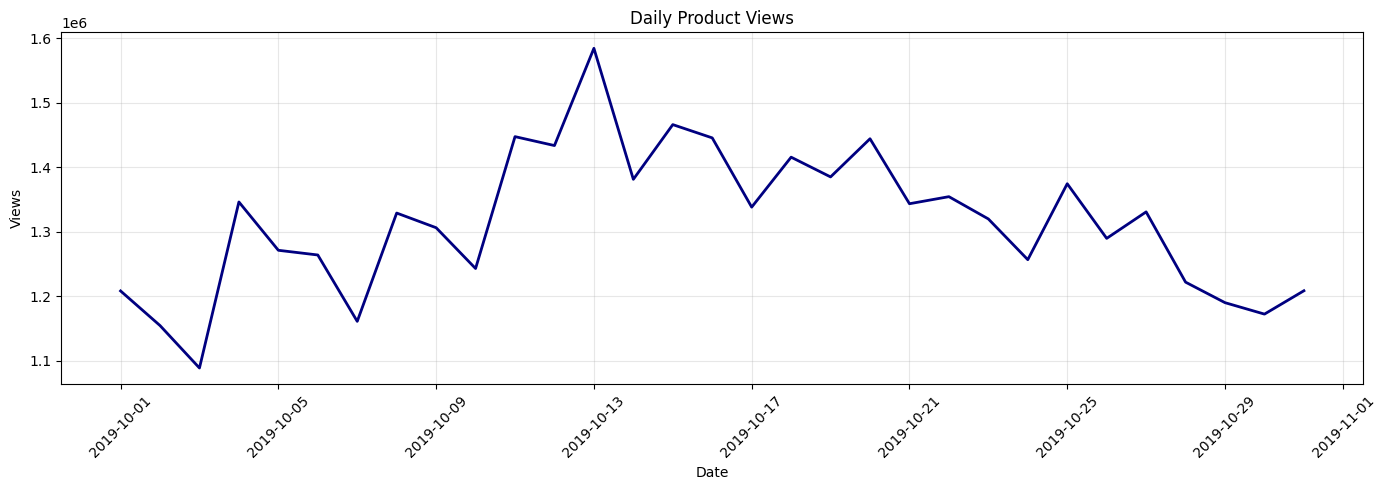

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_activity["event_date"],
    daily_activity["views"],
    linewidth=2,
    color="navy"
)

plt.title("Daily Product Views")
plt.xlabel("Date")
plt.ylabel("Views")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Daily Cart Additions and Purchases

This chart compares daily cart additions and completed purchases throughout the month.

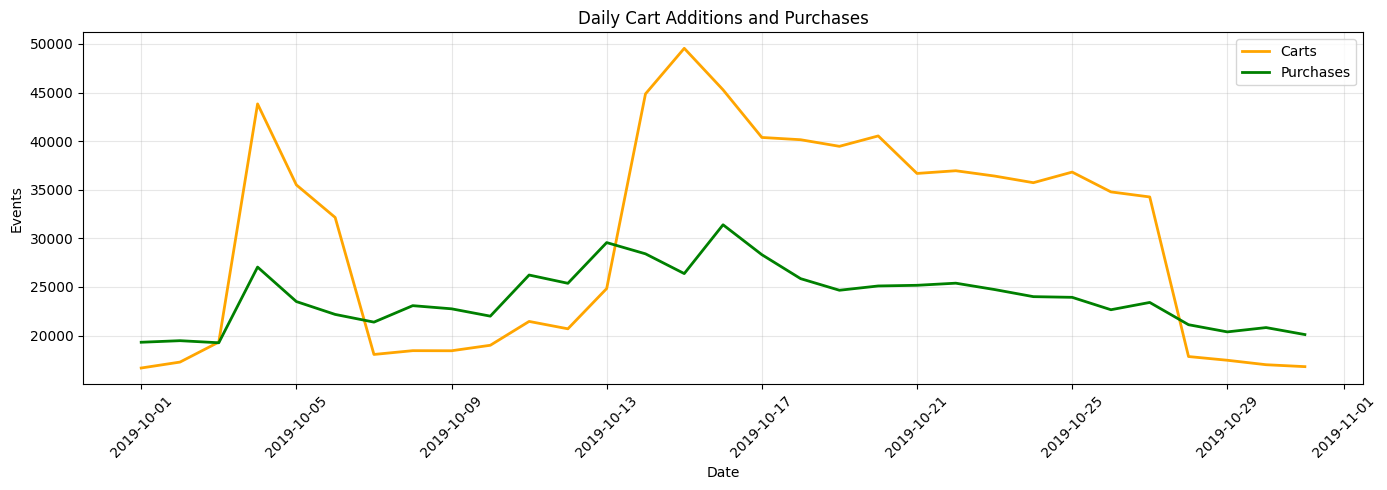

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_activity["event_date"],
    daily_activity["carts"],
    label="Carts",
    linewidth=2,
    color="orange"
)

plt.plot(
    daily_activity["event_date"],
    daily_activity["purchases"],
    label="Purchases",
    linewidth=2,
    color="green"
)

plt.title("Daily Cart Additions and Purchases")
plt.xlabel("Date")
plt.ylabel("Events")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Key Findings

- Product views remain relatively stable throughout the month, with a noticeable increase around mid-October.
- Cart additions and purchases generally follow similar daily trends.
- Purchase activity closely follows changes in cart additions, indicating a consistent conversion pattern.

## Top Categories Analysis

This section identifies the most frequently viewed product categories and highlights which categories attract the highest user interest.

In [ ]:
top_categories = db.sql("""
SELECT
    category_code,
    COUNT(*) AS total_views
FROM events
WHERE
    event_type='view'
    AND category_code IS NOT NULL
GROUP BY category_code
ORDER BY total_views DESC
LIMIT 15
""").pl()

top_categories

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

category_code,total_views
str,i64
"""electronics.smartphone""",10619448
"""electronics.clocks""",1272783
"""computers.notebook""",1106406
"""electronics.video.tv""",1055961
"""electronics.audio.headphone""",1018542
…,…
"""computers.desktop""",417779
"""apparel.shoes.keds""",407593
"""furniture.bedroom.bed""",355314


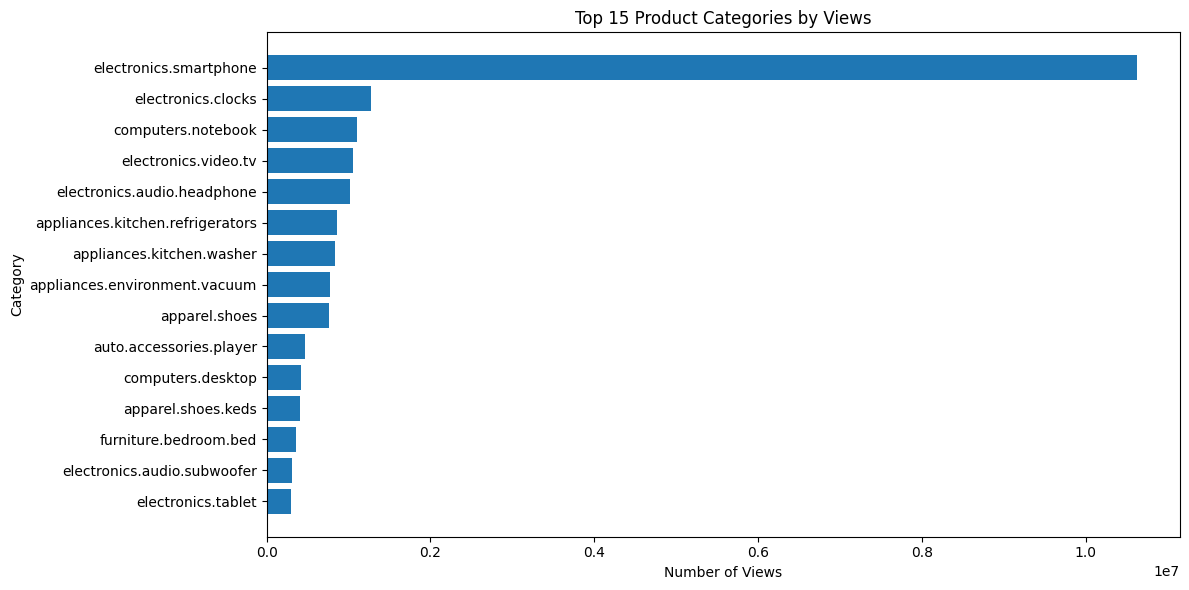

In [ ]:
plt.figure(figsize=(12,6))

plt.barh(
    top_categories["category_code"],
    top_categories["total_views"]
)

plt.title("Top 15 Product Categories by Views")
plt.xlabel("Number of Views")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Key Findings

- A small number of product categories account for a large share of all product views.
- User interest is concentrated in specific product categories rather than evenly distributed across the catalog.
- These popular categories may have a stronger influence on recommendation quality.

## Top Brands Analysis

This section identifies the most frequently viewed brands and examines how user interest is distributed across brands.

In [ ]:
top_brands = db.sql("""
SELECT
    brand,
    COUNT(*) AS total_views
FROM events
WHERE
    event_type = 'view'
    AND brand IS NOT NULL
GROUP BY brand
ORDER BY total_views DESC
LIMIT 15
""").pl()

top_brands

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

brand,total_views
str,i64
"""samsung""",4806630
"""apple""",3770597
"""xiaomi""",2922650
"""huawei""",1045572
"""lucente""",644283
…,…
"""cordiant""",351996
"""lenovo""",330608
"""artel""",325650


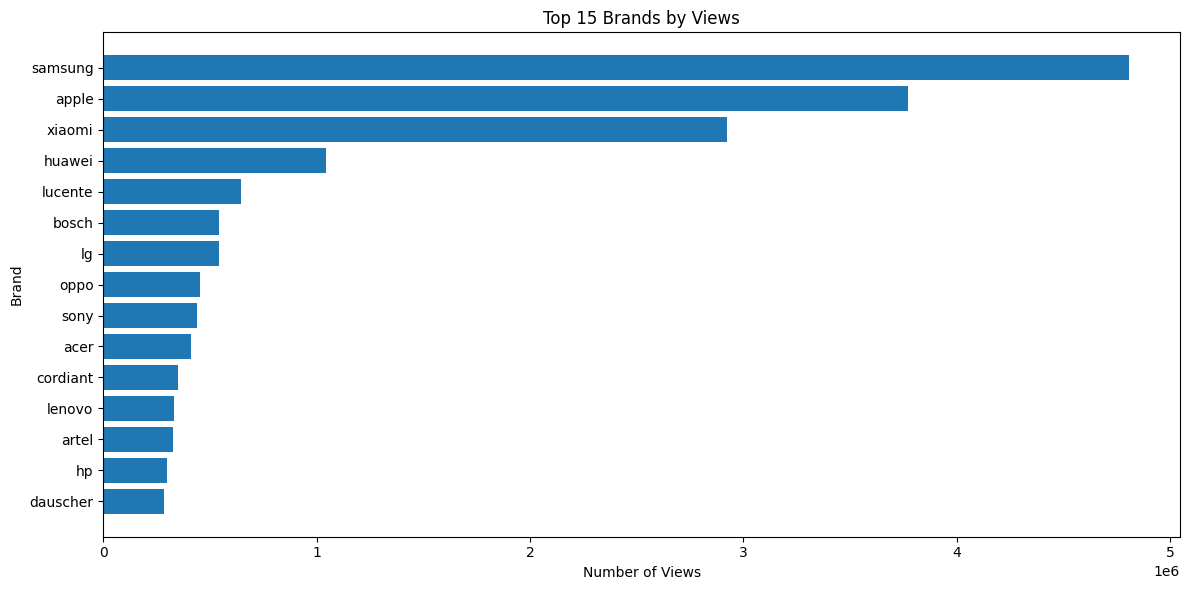

In [ ]:
plt.figure(figsize=(12,6))

plt.barh(
    top_brands["brand"],
    top_brands["total_views"]
)

plt.title("Top 15 Brands by Views")
plt.xlabel("Number of Views")
plt.ylabel("Brand")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Key Findings

- User interest is concentrated among a limited number of brands.
- The most viewed brands receive substantially more attention than the rest of the catalog.
- Brand popularity may be an important behavioral signal for later recommendation analysis.

## Product Price Analysis

This section analyzes product-level prices by assigning a representative price to each unique product.  
Since the same product may appear across multiple events and prices may vary over time, the median price is used for each product.

In [ ]:
product_prices = db.sql("""
SELECT
    product_id,
    MEDIAN(price) AS product_price
FROM events
WHERE price > 0
GROUP BY product_id
""").df()

product_prices.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_id,product_price
0,30100077,267.19
1,5700619,48.91
2,1701218,110.58
3,23000101,8.70
4,1005002,254.54


### Product Price Summary

In [ ]:
product_price_summary = db.sql("""
WITH product_prices AS (
    SELECT
        product_id,
        MEDIAN(price) AS product_price
    FROM events
    WHERE price > 0
    GROUP BY product_id
)

SELECT
    COUNT(*) AS unique_products,
    MIN(product_price) AS min_price,
    AVG(product_price) AS avg_price,
    MEDIAN(product_price) AS median_price,
    MAX(product_price) AS max_price
FROM product_prices
""").df()

product_price_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,unique_products,min_price,avg_price,median_price,max_price
0,165647,0.77,172.176785,68.73,2574.07


### Product Price Percentiles

In [ ]:
product_price_percentiles = db.sql("""
WITH product_prices AS (
    SELECT
        product_id,
        MEDIAN(price) AS product_price
    FROM events
    WHERE price > 0
    GROUP BY product_id
)

SELECT
    quantile_cont(product_price, 0.25) AS q1,
    quantile_cont(product_price, 0.50) AS median,
    quantile_cont(product_price, 0.75) AS q3,
    quantile_cont(product_price, 0.90) AS p90,
    quantile_cont(product_price, 0.95) AS p95,
    quantile_cont(product_price, 0.99) AS p99
FROM product_prices
""").df()

product_price_percentiles

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,q1,median,q3,p90,p95,p99
0,23.42,68.73,182.28,432.44,720.74,1544.18


### Product Price Distribution

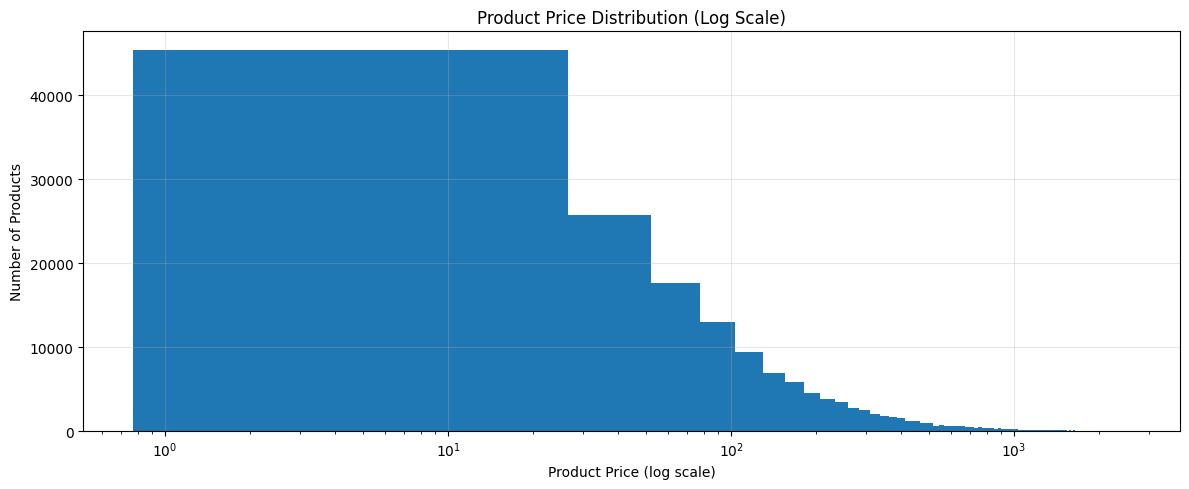

In [ ]:
plt.figure(figsize=(12,5))

plt.hist(product_prices["product_price"], bins=100)

plt.xscale("log")

plt.title("Product Price Distribution (Log Scale)")
plt.xlabel("Product Price (log scale)")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

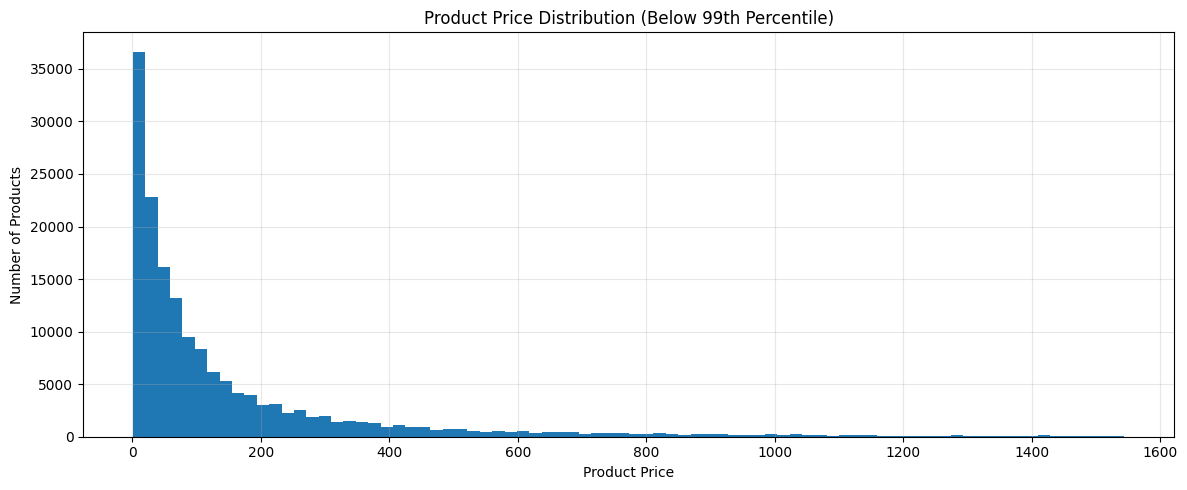

In [ ]:
p99 = product_prices["product_price"].quantile(0.99)

filtered = product_prices[
    product_prices["product_price"] <= p99
]

plt.figure(figsize=(12,5))

plt.hist(filtered["product_price"], bins=80)

plt.title("Product Price Distribution (Below 99th Percentile)")
plt.xlabel("Product Price")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Price Distribution without Extreme Outliers

To better visualize the majority of products, prices above the 99th percentile are excluded from the following distribution.

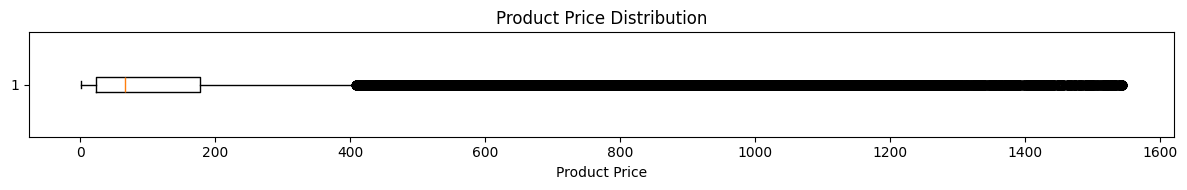

In [ ]:
plt.figure(figsize=(12,2))

plt.boxplot(
    filtered["product_price"],
    vert=False
)

plt.title("Product Price Distribution")

plt.xlabel("Product Price")

plt.tight_layout()
plt.show()

### Key Findings

- Most products are concentrated in low and mid-price ranges.
- The median product price is 68.7, while 75% of products cost less than 182.8.
- The distribution is strongly right-skewed, indicating a relatively small number of premium-priced products.

## User Behavior by Event Type

This section analyzes user behavior by comparing the number of unique users and sessions involved in each event type.

In [ ]:
event_behavior = db.sql("""
SELECT
    event_type,
    COUNT(*) AS total_events,
    COUNT(DISTINCT user_id) AS unique_users,
    COUNT(DISTINCT user_session) AS unique_sessions,
    ROUND(
        COUNT(*) * 1.0 / COUNT(DISTINCT user_id),
        2
    ) AS events_per_user
FROM events
GROUP BY event_type
ORDER BY total_events DESC
""").df()

event_behavior

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,total_events,unique_users,unique_sessions,events_per_user
0,view,40779399,3022130,9242653,13.49
1,cart,926516,337117,573097,2.75
2,purchase,742849,347118,629560,2.14


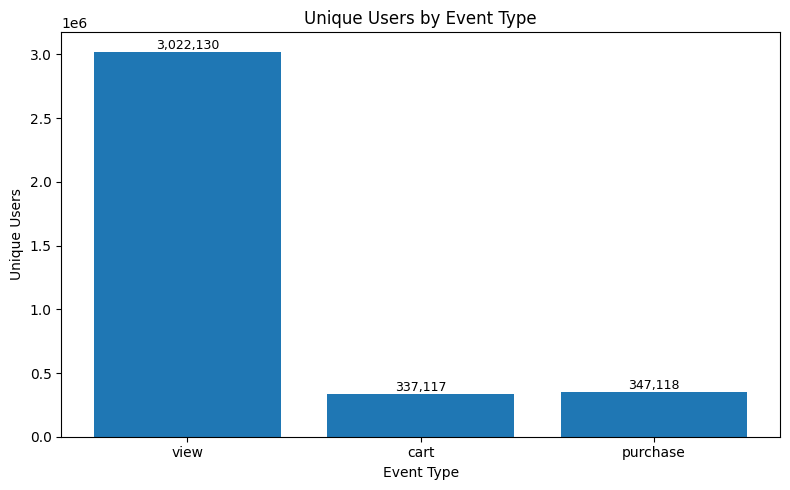

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    event_behavior["event_type"],
    event_behavior["unique_users"]
)

plt.title("Unique Users by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Unique Users")

# Değerleri barların üzerine yaz
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Key Findings

- Product views involve the largest number of unique users and sessions.
- Cart and purchase events involve a substantially smaller user base than product views.
- Purchase events involve a user population similar in size to cart events, suggesting that recorded user journeys do not always strictly follow a view → cart → purchase sequence.

# Conclusion

This exploratory analysis provided a comprehensive overview of user behavior in the e-commerce platform and established a solid foundation for the recommendation system.

The main findings include:

- Product views account for the vast majority of user interactions, while cart additions and purchases represent a much smaller portion of the customer journey.
- A relatively small number of product categories generate most user activity, indicating concentrated customer interest.
- Product prices are highly right-skewed, with most products belonging to the lower and mid-price ranges and only a limited number of premium-priced items.
- Missing values are primarily observed in product categories and brands, while other critical fields remain complete.
- Duplicate event records exist but represent only a very small fraction of the dataset and were preserved because they may correspond to legitimate user actions.

Overall, the dataset demonstrates sufficient quality for behavioral analysis and recommendation system development. The insights obtained during the exploratory phase will guide the feature engineering and modeling stages of the project.

## Next Steps

The next phase of the project will focus on:

- Feature engineering
- User-product interaction matrix creation
- Recommendation model development